In [1]:
%reload_ext autoreload
%autoreload 2

In [20]:
import scipy

from persistence import datasets as dataset_persistence
from src import (
    mappings,
)
from src.adt import preprocessing as adt_preprocessing
from src.logs import get_logger
from src.rna import preprocessing as rna_preprocessing

log = get_logger()

LEVEL = "celltype.l2"

In [12]:
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.simplefilter("ignore", category=PerformanceWarning)
warnings.simplefilter("ignore", category=ImplicitModificationWarning)


In [13]:
# Load the persistence
dataset = dataset_persistence.load_or_create_subsample(subsample_size=10_000,
                                                       level=LEVEL)
rna_dataset, adt_dataset = dataset["rna"], dataset["adt"]

rna_preprocessing.calculate_qc_metrics_in_place(rna_dataset)
rna_preprocessing.normalize_in_place(rna_dataset)
adt_preprocessing.normalize_in_place(adt_dataset)

# Feature selection

# HV Genes
rna_preprocessing.annotate_highly_variable_genes(rna_dataset)
hv_genes = rna_preprocessing.get_highly_variable_genes(rna_dataset)

protein_names = adt_dataset.var["protein_name"]
marker_genes_for_proteins = mappings.get_marker_genes_for_proteins(
    protein_names)
expressed_genes = rna_dataset.var["gene_name"]

expressed_marker_genes_for_proteins = (marker_genes_for_proteins
                                       .intersection(expressed_genes))

genes_of_interest = expressed_marker_genes_for_proteins.union(hv_genes)

genes_of_interest_mask = rna_dataset.var["gene_name"].isin(
    sorted(genes_of_interest))
rna_of_interest_dataset = rna_dataset[:, genes_of_interest_mask].copy()

# Filtering
rna_of_interest_dataset = rna_preprocessing.apply_basic_filtering(
    rna_of_interest_dataset)

# Scaling
rna_preprocessing.scale_in_place(rna_of_interest_dataset)

rna_preprocessing.rank_transform_in_place(rna_of_interest_dataset)


2026-06-28 17:24:01 [INFO] (datasets.py) Load or create dataset: subsample size=10000, level=celltype.l2
2026-06-28 17:24:01 [INFO] (datasets.py) Dataset exists at /Users/inbad/workspace/studium/data_science_for_life_science_summer_2026_project/persistence/processed/multi_modal_dataset__subsample_n_10000_seed_42.h5mu
2026-06-28 17:24:01 [INFO] (datasets.py) Skipping creation [force_recreate=False]


In [14]:
from src import ground_truth

driver_gene_ground_truth = ground_truth.build_ground_truth(
    adt_dataset, LEVEL, genes_of_interest)

In [7]:

from sklearn.model_selection import train_test_split

# 1. Extract all global cell barcodes (obs_names) shared across your modalities
all_cell_barcodes = rna_of_interest_dataset.obs_names.to_list()

# 2. Split the barcodes into Train (70%), Validation (15%), and Test (15%)
# First split off the 15% test barcodes
barcodes_temp, barcodes_test = train_test_split(
    all_cell_barcodes, test_size=0.15, random_state=42
)

# Split the remaining 85% into train and validation
# 15 / 85 is approximately 0.1765
barcodes_train, barcodes_val = train_test_split(
    barcodes_temp, test_size=0.1765, random_state=42
)

# 3. Create the subsetted MuData objects
mdata_train = dataset[barcodes_train, :].copy()
mdata_val = dataset[barcodes_val, :].copy()
mdata_test = dataset[barcodes_test, :].copy()

print("--- MUDATA MULTI-MODAL SPLIT VERIFICATION ---")
print(f"Train MuData (70%):      {mdata_train.n_obs} cells")
print(f"Validation MuData (15%): {mdata_val.n_obs} cells")
print(f"Test MuData (15%):       {mdata_test.n_obs} cells")

# Verify that an underlying modality (e.g., 'rna') was split perfectly inline
if 'rna' in dataset.mod:
    print(
        f"-> Verified underlying RNA shape in Train: {mdata_train['rna'].shape}")

--- MUDATA MULTI-MODAL SPLIT VERIFICATION ---
Train MuData (70%):      6999 cells
Validation MuData (15%): 1501 cells
Test MuData (15%):       1501 cells
-> Verified underlying RNA shape in Train: (6999, 33538)


In [10]:
mdata_train.write("../data/split/70_15_15/seed_42/mdata_train.h5mu")
mdata_val.write("../data/split/70_15_15/seed_42/mdata_val.h5mu")
mdata_test.write("../data/split/70_15_15/seed_42/mdata_test.h5mu")

In [17]:
target_matrix = rna_preprocessing.build_target_matrix(rna_of_interest_dataset, LEVEL)

In [119]:
import torch

def extract_dense_features(adata_modality):
    if scipy.sparse.issparse(adata_modality.X):
        return adata_modality.X.toarray()
    return adata_modality.X

train_rna_dataset = mdata_train['rna']
X_train_np = extract_dense_features(mdata_train['rna'])
Y_train_np = target_matrix.loc[train_rna_dataset.obs_names].values

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_np, dtype=torch.float32)

val_rna_dataset = mdata_val['rna']
X_val_np = extract_dense_features(mdata_val['rna'])
Y_val_np = target_matrix.loc[val_rna_dataset.obs_names].values

X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_np, dtype=torch.float32)



In [120]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [97]:
from torch import nn


class GeneExpressionMLP(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.3):
        super(GeneExpressionMLP, self).__init__()

        # A robust 3-layer architecture for scaling single-cell data
        self.network = nn.Sequential(
            # Layer 1: Input (Number of Genes) -> 512 hidden nodes
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            # Layer 2: 512 -> 256 hidden nodes
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Tanh(),
            nn.Dropout(dropout_rate),

            # Layer 3: 256 -> Output (Your 30 Cell Types)
            # We output raw logits (no sigmoid here, BCEWithLogitsLoss handles it safely)
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.network(x)

In [102]:
from torch import optim

# Track dimensions from your tensors
input_dim = X_train_tensor.shape[1]   # Number of genes
output_dim = Y_train_tensor.shape[1] # Number of cell types

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mlp_model = GeneExpressionMLP(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

In [104]:
EPOCHS = 15

print("Starting MLP training loop...")
print("-" * 40)

for epoch in range(EPOCHS):
    mlp_model.train() # Explicitly set model to training mode (enables Dropout/BatchNorm)
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        # Move the batched chunk data to the same hardware device as the model
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # 1. Clear previous gradients
        optimizer.zero_grad()

        # 2. Forward Pass: Make predictions
        predictions = mlp_model(batch_x)

        # 3. Calculate error
        loss = criterion(predictions, batch_y)

        # 4. Backward Pass: Calculate adjustments
        loss.backward()

        # 5. Optimization Step: Update model weights
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    # Calculate average loss for this epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {epoch_loss:.4f}")

print("-" * 40)
print("Training fit complete! The model weights are now trained.")

Starting MLP training loop...
----------------------------------------
Epoch 01/15 | Train Loss: 0.0636
Epoch 02/15 | Train Loss: 0.0348
Epoch 03/15 | Train Loss: 0.0182
Epoch 04/15 | Train Loss: 0.0108
Epoch 05/15 | Train Loss: 0.0067
Epoch 06/15 | Train Loss: 0.0046
Epoch 07/15 | Train Loss: 0.0033
Epoch 08/15 | Train Loss: 0.0025
Epoch 09/15 | Train Loss: 0.0019
Epoch 10/15 | Train Loss: 0.0016
Epoch 11/15 | Train Loss: 0.0013
Epoch 12/15 | Train Loss: 0.0011
Epoch 13/15 | Train Loss: 0.0009
Epoch 14/15 | Train Loss: 0.0008
Epoch 15/15 | Train Loss: 0.0007
----------------------------------------
Training fit complete! The model weights are now trained.


In [121]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

# 1. Put model into pure evaluation/prediction mode
mlp_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

all_true_labels = []
all_pred_probabilities = []

# 2. Run predictions without tracking gradients
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        # Move batch to whichever device the model is currently using
        batch_x = batch_x.to(device)

        # Get raw logit outputs from the model
        logits = mlp_model(batch_x)

        # Apply Sigmoid to squash logits into actual probabilities [0, 1]
        probs = torch.sigmoid(logits)

        # Collect outputs and true labels as numpy arrays
        all_pred_probabilities.append(probs.cpu().numpy())
        all_true_labels.append(batch_y.numpy())

# Combine all batches into single matrices
Y_val_true = np.vstack(all_true_labels)
Y_val_pred = np.vstack(all_pred_probabilities)

# 3. Calculate Performance Metric
# Macro AUC-ROC computes the score for each of your 30 cell types independently and averages them.
# A score of 0.5 is random guessing; 1.0 is a flawless predictive model.
macro_auc = roc_auc_score(Y_val_true, Y_val_pred, average='macro')

print("--- INFERENCE PERFORMANCE VERIFICATION ---")
print(f"Validation Macro AUC-ROC: {macro_auc:.4f}")
if macro_auc > 0.80:
    print("🔥 Success! The MLP has strong predictive capability. Your model is validated.")
else:
    print("⚠️ The model performance is low. The explanations from IG might be noisy.")

--- INFERENCE PERFORMANCE VERIFICATION ---
Validation Macro AUC-ROC: 0.9944
🔥 Success! The MLP has strong predictive capability. Your model is validated.


In [122]:
# Save the model's underlying learned weights matrix
torch.save(mlp_model.state_dict(),
           '../persistence/models/trained_models/split_70_seed_0/model.pt')

Model successfully persisted to disk as 'validated_gene_mlp.pt'!


In [125]:
input_dim = X_train_tensor.shape[1]   # Number of genes
output_dim = Y_train_tensor.shape[1]  # Number of cell types

# Initialize a fresh, untrained instance of your model
loaded_model = GeneExpressionMLP(input_dim, output_dim)

state_dict = torch.load('../persistence/models/trained_models/split_70_seed_0/model.pt')

# 3. Inject the weights into the empty shell
loaded_model.load_state_dict(state_dict)

# 4. Move the fully built model to your target hardware device and set to evaluation mode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

GeneExpressionMLP(
  (network): Sequential(
    (0): Linear(in_features=33538, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): Tanh()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): Tanh()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=30, bias=True)
  )
)

In [137]:
import torch
import pandas as pd
from captum.attr import IntegratedGradients

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize the Integrated Gradients tool with your loaded model
# Captum will automatically track the internal gradients of this specific model
ig = IntegratedGradients(loaded_model)

# 2. Establish a Baseline (A matrix of pure zeros matching your input tensor shape)
# This represents a "blank cell" with absolutely zero gene expression.
baseline = torch.zeros_like(X_train_tensor).to(device)

# Ensure the input tensor is sitting on the correct hardware device
X_train_tensor = X_train_tensor.to(device)

# Initialize an empty dictionary to store the aggregated vectors
mlp_attributions = {}

print("Computing Integrated Gradients across all cell types...")
print("-" * 50)

# 3. Loop through each of your 30 cell types
for class_idx, cell_type in enumerate(target_matrix.columns):
    print(f"Processing attributions for: {cell_type}")

    # 1. Slice out ONLY the cells that express this cell type baseline
    true_cell_mask = (Y_train_np[:, class_idx] == 1)
    X_train_subset = X_train_tensor[true_cell_mask].to(device)
    subset_baseline = torch.zeros_like(X_train_subset).to(device)

    # target=class_idx tells Captum exactly which output neuron's gradients to track
    # internal_batch_size helps prevent GPU out-of-memory errors by chunking the integration steps
    raw_attributions = ig.attribute(
        inputs=X_train_subset,
        baselines=subset_baseline,
        target=class_idx,
        n_steps=50,
        internal_batch_size=X_train_subset.shape[0]
    )

    # Convert the raw cell-by-gene attributions back to a CPU NumPy array
    raw_attr_np = raw_attributions.detach().cpu().numpy()

    # Identify which cells actually belong to this true target class
    # We index into our original true binary labels matrix
    true_cell_mask = (Y_train_np[:, class_idx] == 1)

    mean_attributions = raw_attributions.detach().cpu().numpy().mean(axis=0)
    mlp_attributions[cell_type] = mean_attributions

print("-" * 50)
print("IG Computation Complete!")

# 4. Package into your exact standardized benchmarking shape: (n_genes, n_cell_types)
# Pull the exact gene names from your original training DataFrame's columns
gene_names = mdata_train['rna'].var["gene_name"] # or X_train.columns depending on your setup

mlp_ig_results_df = pd.DataFrame(
    mlp_attributions,
    index=gene_names
)

# Persist the final matrix results to disk so you don't lose the calculations
mlp_ig_results_df.to_csv("mlp_integrated_gradients_results.csv")
print("Saved final attribution matrix cleanly to disk as 'mlp_integrated_gradients_results.csv'.")

Computing Integrated Gradients across all cell types...
--------------------------------------------------
Processing attributions for: ASDC
Processing attributions for: B intermediate
Processing attributions for: B memory
Processing attributions for: B naive
Processing attributions for: CD4 CTL
Processing attributions for: CD4 Naive
Processing attributions for: CD4 Proliferating
Processing attributions for: CD4 TCM
Processing attributions for: CD4 TEM
Processing attributions for: CD8 Naive
Processing attributions for: CD8 Proliferating
Processing attributions for: CD8 TCM
Processing attributions for: CD8 TEM
Processing attributions for: CD14 Mono
Processing attributions for: CD16 Mono
Processing attributions for: Eryth
Processing attributions for: HSPC
Processing attributions for: ILC
Processing attributions for: MAIT
Processing attributions for: NK
Processing attributions for: NK Proliferating
Processing attributions for: NK_CD56bright
Processing attributions for: Plasmablast
Process

In [147]:
from src import ground_truth

driver_gene_ground_truth = ground_truth.build_ground_truth(
    adt_dataset, LEVEL, genes_of_interest)

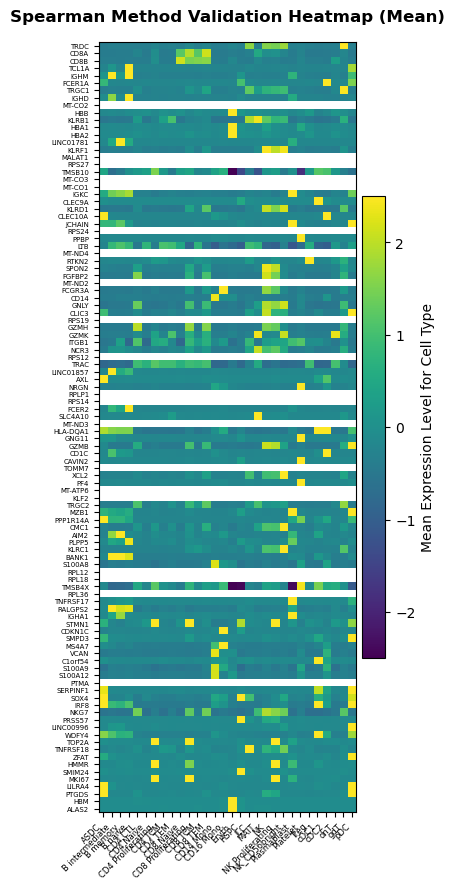

In [148]:
from measures.validation import heatmap as heatmap_validation

mlp_ig_heatmap_results_df = heatmap_validation.calculate_validation_data(
    mlp_ig_results_df)
heatmap_validation.plot(mlp_ig_heatmap_results_df, rna_of_interest_dataset,
                        LEVEL)

In [149]:
from measures.validation import hit_miss_rates as hit_miss_validation

mlp_ig_hit_miss_validation_df = hit_miss_validation.calculate_validation_data(
    mlp_ig_results_df, driver_gene_ground_truth)

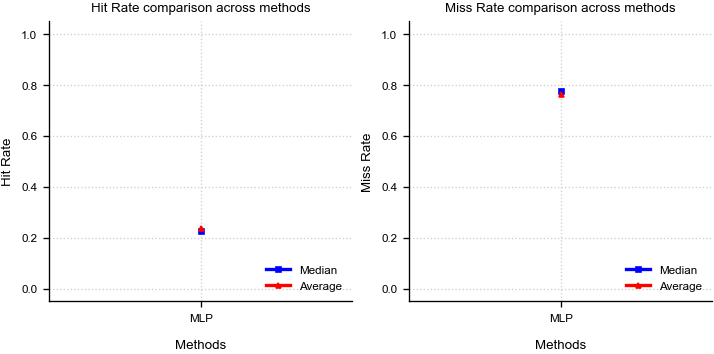

In [150]:
names = ["MLP"]
summaries = [mlp_ig_hit_miss_validation_df]

hit_miss_validation.plot(summaries, names)

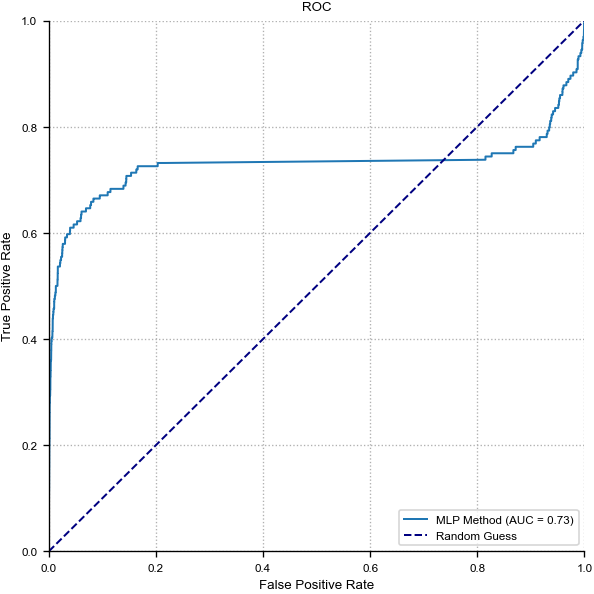

In [160]:
from measures.validation import roc_curve

names = ["MLP"]
results = [mlp_ig_results_df]

roc_curve.plot(results, names, driver_gene_ground_truth)

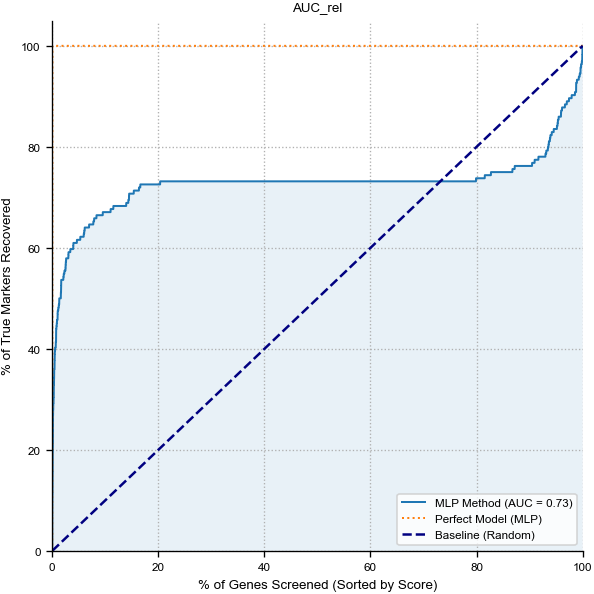

In [161]:
from measures.benchmarking import driver_recovery_metric

results = [mlp_ig_results_df]
names = ["MLP"]

auc_rel_mlp = driver_recovery_metric.compute_auc_rel(mlp_ig_results_df, driver_gene_ground_truth)

driver_recovery_metric.plot(results, names, driver_gene_ground_truth)